# 18.6 Markov Decision Process

##### System

In [1]:
import numpy as np

n_states = 3
n_actions = 3

transition_probas = [
    [[0.7, 0.3, 0], [1, 0, 0], [0.8, 0.2, 0]],
    [[0, 1, 0], None, [0, 0, 1]],
    [None, [0.8, 0.1, 0.1], None],
]
rewards = [
    [[10, 0, None], [0, None, None], [0, 0, None]],
    [[None, 0, None], None, [None, None, -50]],
    [None, [40, 0, 0], None],
]
possible_actions = [
    [0, 1, 2],
    [0, 2],
    [1],
]

##### Q-Value Iteration Algorithm

In [2]:
# Initialize q
gamma = 0.90
q = np.full((n_states, n_actions), -np.inf, dtype=np.float32)

for row_q, row_pa in zip(q, possible_actions):
    row_q[row_pa] = 0.0

q

array([[  0.,   0.,   0.],
       [  0., -inf,   0.],
       [-inf,   0., -inf]], dtype=float32)

In [3]:
# Update q
n_epochs = 50
q_00_iteration = []

for epoch in range(n_epochs):
    q_prev = q.copy()
    for state, acts in enumerate(possible_actions):
        for act in acts:
            delta = 0
            for state_prime, (transition_proba, reward) in enumerate(zip(transition_probas[state][act], rewards[state][act])):
                if reward is None: 
                    continue 
                delta += transition_proba * (reward + gamma * np.max(q_prev[state_prime]))
            q[state, act] = delta
            q_00_iteration.append(q[0, 0])
q

array([[18.918917, 17.027025, 13.62162 ],
       [ 0.      ,      -inf, -4.879717],
       [     -inf, 50.133648,      -inf]], dtype=float32)

In [4]:
np.argmax(q, axis=1)

array([0, 0, 1])

# 18.9 Q-Learning

In [5]:
from typing import Tuple


def step(state: int, action: int) -> Tuple[int, float]:
    probas = transition_probas[state][action]
    state_next = np.random.choice([0, 1, 2], p=probas)
    reward = rewards[state][action][state_next]
    
    return state_next, reward

def exploration_policy(state: int) -> int:
    return np.random.choice(possible_actions[state])


alpha_0 = 0.05
decay = 0.005
n_iterations = 10_000
state = 0
q_00_learning = []

for iteration in range(n_iterations):
   action = exploration_policy(state=state) 
   state_next, reward = step(state=state, action=action)
   alpha = alpha_0 / (1 + iteration * decay)
   q[state, action] = (1 - alpha) * q[state, action] + alpha * (reward + gamma * np.max(q[state_next]))
   q_00_learning.append(q[0, 0])
   state = state_next

q

array([[19.91038 , 17.918076, 14.328857],
       [ 0.      ,      -inf, -4.531228],
       [     -inf, 50.90839 ,      -inf]], dtype=float32)

# Convergence Speed

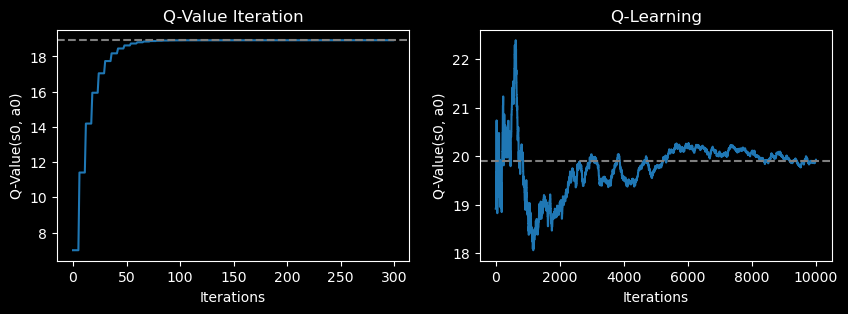

In [12]:
from typing import Sequence

import matplotlib.pyplot as plt

def plot_qs_00(ax: plt.Axes, q_00: Sequence[float], title: str) -> None:
    ax.plot(q_00, "tab:blue")
    ax.axhline(q_00[-1], c="tab:gray", ls="--")
    ax.set(xlabel="Iterations", ylabel="Q-Value(s0, a0)", title=title)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))
plot_qs_00(axs[0], q_00_iteration, "Q-Value Iteration")
plot_qs_00(axs[1], q_00_learning, "Q-Learning")